# LiF on Silicon

In addition to the 1 mm data on the fused quartz sample Woollam have now sent the 2 m scans for two LiF on Si deposits, one on unetched and one on etched. Let's see how they look using the new quintic fits.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from DepositData5 import DepositData

## The Unetched Wafer

In [2]:
Siu= DepositData.from_file('Run9_17_SiUnetched_2mm.txt', 'Unetched Si 2mm')

Using t1
Using ref_index
Using roughness


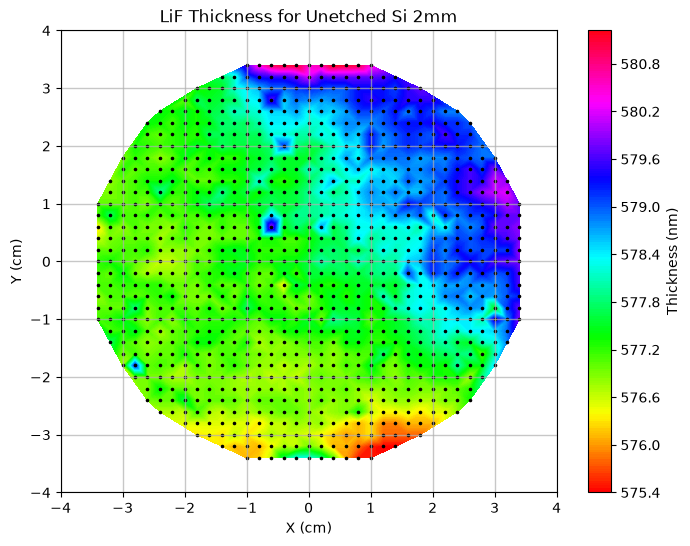

In [3]:
Siu.Ron_plot()

So this looks as though the peak of the curve is off the top edge. The deposit is also unusually flat.

In [4]:
# Scaled initial parameters
ipg = [ 5.78,  1.045e+00, -9.325,  1.174,  1.0,  1.0, 1.0]

def quint_fit(p, a):
    return DepositData.fit_helper(p, a, 'angled_quintic')

In [5]:
Siuf = Siu.fit_to(quint_fit, ipg)
print(Siuf)

  message: Desired error not necessarily achieved due to precision loss.
  success: False
   status: 2
      fun: 167.3984257848206
        x: [ 5.773e+00  2.275e+01  5.708e-01 -2.063e+00 -7.472e-02
             1.211e+00 -9.776e-02]
      nit: 24
      jac: [ 1.293e-03  5.150e-04 -7.248e-05  4.578e-05  9.537e-05
             1.469e-04 -8.583e-05]
 hess_inv: [[ 1.153e-07  4.117e-06 ...  1.436e-06  5.155e-06]
            [ 4.117e-06  9.886e-04 ...  1.470e-04  8.457e-04]
            ...
            [ 1.436e-06  1.470e-04 ...  6.832e-05  1.687e-04]
            [ 5.155e-06  8.457e-04 ...  1.687e-04  7.862e-04]]
     nfev: 716
     njev: 88


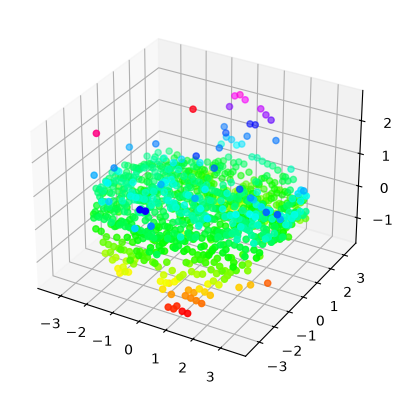

In [6]:
Siu.resid_plot3D()

Fit looks very good with just a few outliers and only shape the low edge on the near corner. Here is the fit.

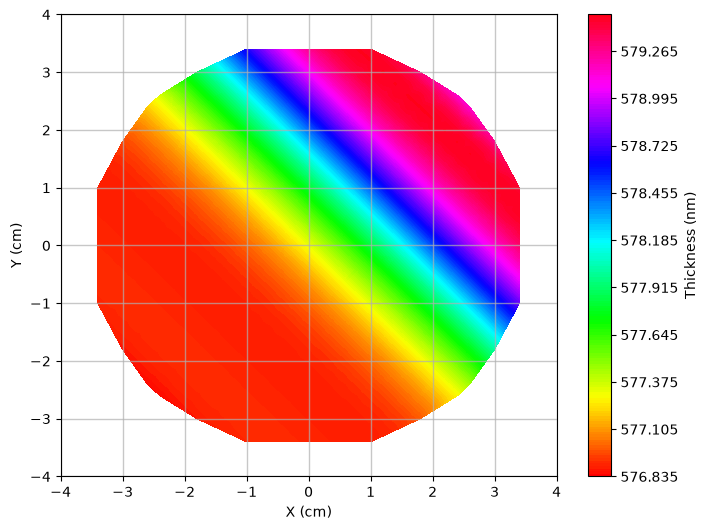

In [7]:
Siu.contour_plot(Siu.fit_z)

Almost perfectly linear with a range of less then 3 nm, 0.5% of the thickness.

For a different view here is the contour plot of the residuals.

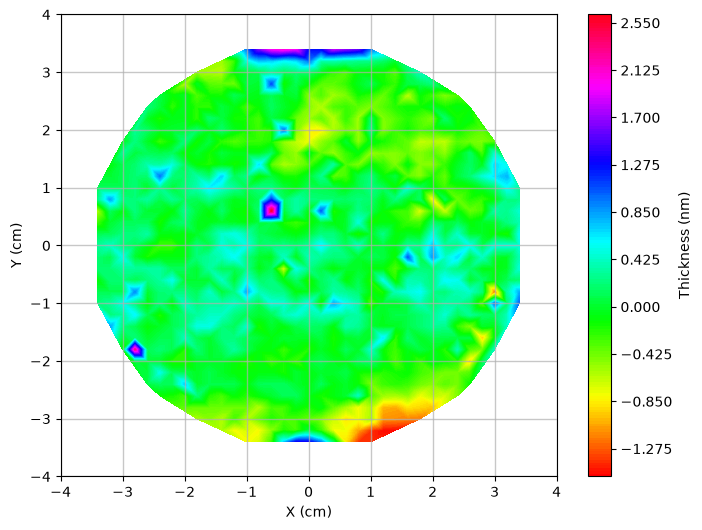

In [8]:
Siu.contour_plot(Siu.resids)

This is about as flat as we have had recently and almost all the shape is a linear tilt. I ought to figure out the variation across the useful area at some point. Meantime onto the etched wafer, which is much less flat.

## The Etched Wafer

In [9]:
Sie = DepositData.from_file('Run9_17_SiEtched_2mm.txt', 'Etched Si 2mm')

Using t1
Using ref_index
Using roughness


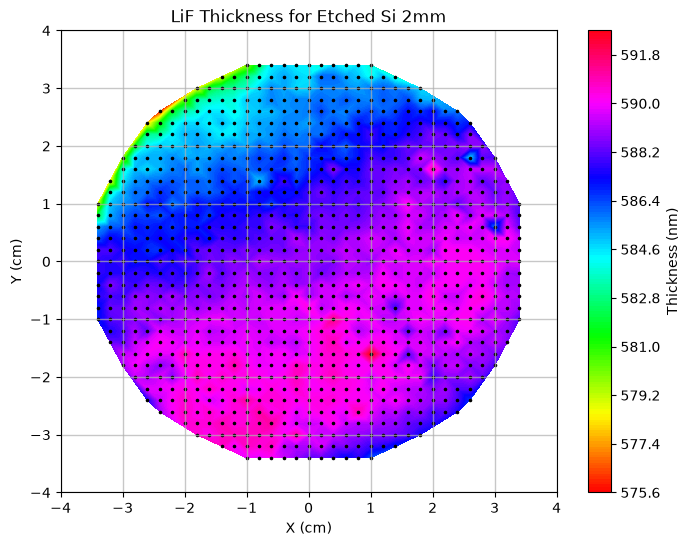

In [10]:
Sie.Ron_plot()

First thing to note is that the angle is markedly different, rotated about 90° from the unetched wafer. Second the overall range is a lot greater. Third, the peak is back within the wafer so we will see more curvature.

In [11]:
# Scaled initial parameters
ipe = [ 5.86,  -0.8e+00, -9.325,  1.174,  1.0,  1.0, 1.0]

Sief = Sie.fit_to(quint_fit, ipe)
print(Sief)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 531.5270033199308
        x: [ 5.889e+00  2.090e+00  1.180e+00  1.035e+00 -7.858e-01
             2.376e+00  4.846e-01]
      nit: 19
      jac: [ 0.000e+00 -1.678e-04 -1.297e-04  1.221e-04 -4.578e-05
             1.526e-05  1.068e-04]
 hess_inv: [[ 1.515e-07 -9.010e-08 ... -5.106e-05 -1.425e-07]
            [-9.010e-08  9.688e-05 ...  2.574e-04  3.157e-04]
            ...
            [-5.106e-05  2.574e-04 ...  5.186e-02  7.452e-04]
            [-1.425e-07  3.157e-04 ...  7.452e-04  1.719e-02]]
     nfev: 208
     njev: 26


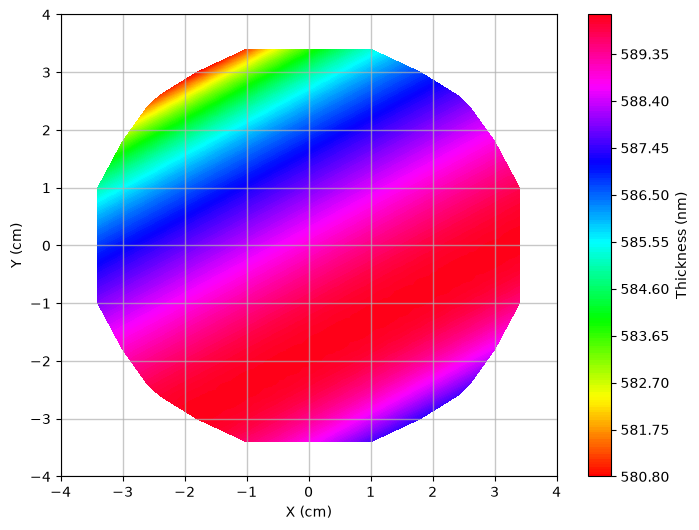

In [12]:
Sie.contour_plot(Sie.fit_z)

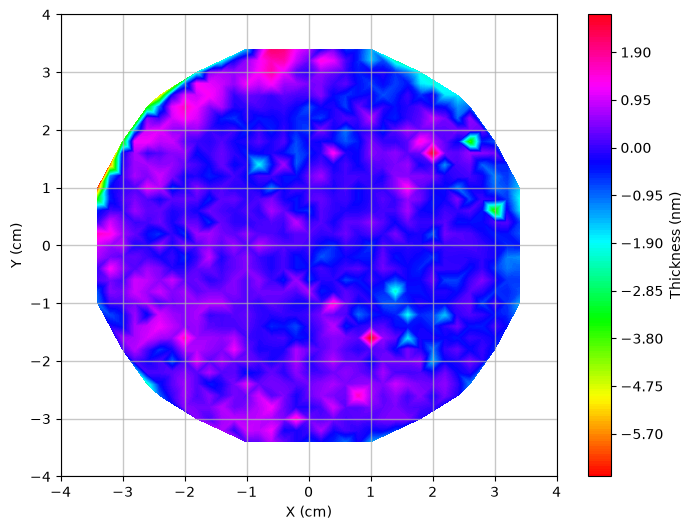

In [13]:
Sie.contour_plot(Sie.resids)

Well, that is interesting. There is a large residual shape. Let's try to visualize it.

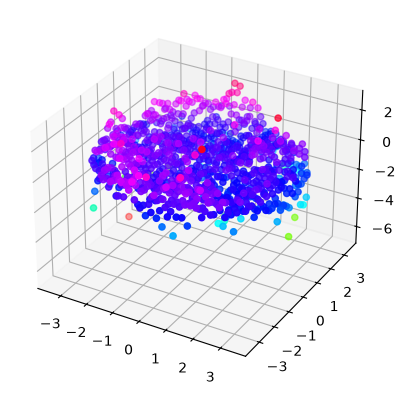

In [14]:
Sie.resid_plot3D()

By playing with the viewpoint in Spider I was able to get this version of the residual plot which makes it clear that the residuals are largely flat (within 1 nm) but there is a worse than usual edge drop off.

![Etched Residuals](Run9_17_26EtchedResid3D.png)

So within the area that we care about this is as good as any deposit we have seen except for the large tilt, almost 10 nm from one side of the wafer to the other.

Are we learning that where the wafer is on the platter is the most important thing in determining the flatness of the surface?